# Image Classification Project
This notebook contains the complete pipeline for image classification, including data loading, preprocessing, model training, and ensemble methods for Kaggle submission.

In [4]:
# 1. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. Import essential libraries
import os
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 3. Define paths (Adjust 'TU_CARPETA' to the actual path in your Drive)
ruta_drive = '/content/drive/MyDrive/Proyecto_ML/'
ruta_base = '/content/dataset/'

# Create local directory for extraction
os.makedirs(ruta_base, exist_ok=True)

# 4. Extract zip files to the local Colab environment
print("Extracting training data...")
with zipfile.ZipFile(ruta_drive + 'x_train.zip', 'r') as zip_ref:
    zip_ref.extractall(ruta_base + 'x_train')

print("Extracting test data...")
with zipfile.ZipFile(ruta_drive + 'x_test.zip', 'r') as zip_ref:
    zip_ref.extractall(ruta_base + 'x_test')

# 5. Load training labels and submission example
y_train = pd.read_csv(ruta_drive + 'y_train_v2.csv')
submission_ejemplo = pd.read_csv(ruta_drive + 'y_test_submission_example_v2.csv')

print("Data loaded successfully.")
print(y_train.head())

Mounted at /content/drive
Extracting training data...
Extracting test data...
Data loaded successfully.
   id  target
0   0       0
1   1       1
2   2       0
3   3       2
4   4       2


## Data Preprocessing
In this section, we define image parameters, locate the dataset, and implement a loading function to process and split the data into training and validation sets.

In [5]:
# Data Preprocessing
import cv2
import glob
from tqdm import tqdm
from sklearn.model_selection import train_test_split

# 1. Parameter configuration
IMG_SIZE = 64

# 2. Automatic search for the correct path
print("Searching for exact image location...")
rutas_png = glob.glob(ruta_base + 'x_train/**/*.png', recursive=True)

if len(rutas_png) == 0:
    raise ValueError("No .png images found! Check if extraction worked in Step 1.")

# Take the path of the first image found and extract its directory
ruta_train_img_real = os.path.dirname(rutas_png[0]) + '/'
print(f"Images found in: {ruta_train_img_real}")

# 3. Loading function
def cargar_y_procesar_datos(ruta_img, df_labels):
    imagenes = []
    etiquetas = []

    for index, row in tqdm(df_labels.iterrows(), total=df_labels.shape[0]):
        # Resolve offset: CSV index 0 = image 1
        img_name = f"img_{index + 1}.png"
        img_path = os.path.join(ruta_img, img_name)

        if os.path.exists(img_path):
            img = cv2.imread(img_path, cv2.IMREAD_COLOR)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            imagenes.append(img)
            etiquetas.append(row.iloc[-1])
        else:
            print(f"Warning: {img_name} not found")

    X = np.array(imagenes, dtype='float32') / 255.0
    y = np.array(etiquetas, dtype='int32')

    return X, y

# 4. Execute function with corrected path
X_full, y_full = cargar_y_procesar_datos(ruta_train_img_real, y_train)

print(f"\nImage tensor shape: {X_full.shape}")
print(f"Label tensor shape: {y_full.shape}")

# 5. Split into Training and Validation (80% - 20%)
X_train, X_val, y_train_split, y_val_split = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42, stratify=y_full
)

print(f"Training images: {X_train.shape[0]}")
print(f"Validation images: {X_val.shape[0]}")

Searching for exact image location...
Images found in: /content/dataset/x_train/


100%|██████████| 9227/9227 [00:02<00:00, 4230.16it/s]



Image tensor shape: (9227, 64, 64, 3)
Label tensor shape: (9227,)
Training images: 7381
Validation images: 1846


## Model Architecture and Training
We define a Convolutional Neural Network (CNN) and train it using the prepared dataset, monitoring its accuracy and loss evolution.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,716 (2.61 MB)

 Trainable params: 683,716 (2.61 MB)

 Non-trainable params: 0 (0.00 B)


Starting training...
Epoch 1/15
231/231 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.6729 - loss: 0.7563 - val_accuracy: 0.8072 - val_loss: 0.4620
Epoch 2/15
231/231 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8092 - loss: 0.4618 - val_accuracy: 0.8776 - val_loss: 0.3288
Epoch 3/15
231/231 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8521 - loss: 0.3713 - val_accuracy: 0.8879 - val_loss: 0.2694
Epoch 4/15
231/231 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8755 - loss: 0.3141 - val_accuracy: 0.8992 - val_loss: 0.2666
Epoch 5/15
231/231 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8874 - loss: 0.2857 - val_accuracy: 0.9225 - val_loss: 0.2080
Epoch 6/15
231/231 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9064 - loss: 0.2447 - val_accuracy: 0.9177 - val_loss: 0.2009
Epoch 7/15
231/231 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9092 - loss: 0.2244 - val_accuracy: 0.9204 - val_loss: 0.1933
Epoch 8/15
231/231 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9206 - loss: 0

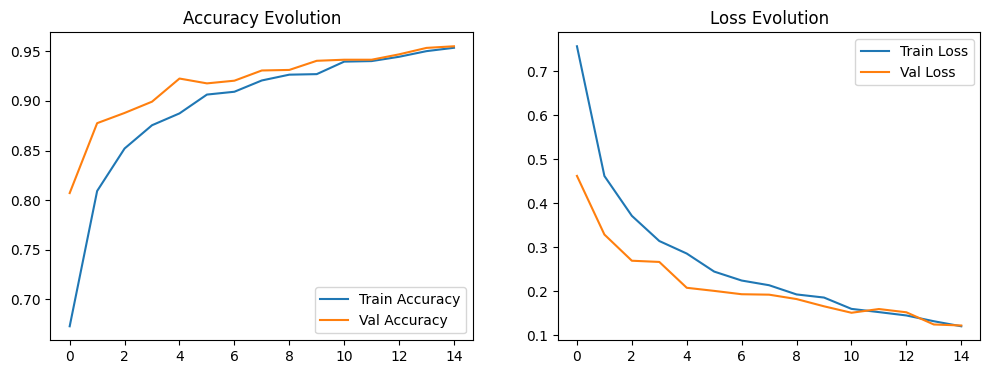

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# 1. Define CNN architecture
modelo_cnn = Sequential([
    # First convolutional layer (extracts basic patterns)
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D((2, 2)),

    # Second convolutional layer (extracts more complex patterns)
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    # Third convolutional layer
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    # Flatten data for final layers
    Flatten(),

    # Dense layer (neurons connected to previous layer)
    Dense(128, activation='relu'),
    # Dropout to randomly turn off neurons and prevent overfitting
    Dropout(0.5),

    # Output layer: 4 neurons (one per class) with softmax activation for probabilities
    Dense(4, activation='softmax')
])

# 2. Compile model
# Using 'sparse_categorical_crossentropy' for integer labels (0, 1, 2, 3)
modelo_cnn.compile(optimizer=Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Architecture summary
modelo_cnn.summary()

# 3. Train model
print("\nStarting training...")
historial = modelo_cnn.fit(
    X_train, y_train_split,
    epochs=15, # Total passes through data
    batch_size=32, # Images processed before weight update
    validation_data=(X_val, y_val_split)
)

# 4. Visualize performance
def plot_historial(hist):
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))

    # Accuracy Plot
    axs[0].plot(hist.history['accuracy'], label='Train Accuracy')
    axs[0].plot(hist.history['val_accuracy'], label='Val Accuracy')
    axs[0].set_title('Accuracy Evolution')
    axs[0].legend()

    # Loss Plot
    axs[1].plot(hist.history['loss'], label='Train Loss')
    axs[1].plot(hist.history['val_loss'], label='Val Loss')
    axs[1].set_title('Loss Evolution')
    axs[1].legend()

    plt.show()

plot_historial(historial)

## Model Evaluation and Export
We evaluate the model's performance on the validation set using a classification report and a confusion matrix, then save the model and generate the first submission file.

Evaluating model on validation set...
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step

--- CLASSIFICATION REPORT (F1-Score) ---
              precision    recall  f1-score   support

    0 People       0.99      1.00      0.99       293
    1 Person       0.95      0.98      0.96       757
    2 People       0.97      0.92      0.94       601
    3 People       0.89      0.90      0.90       195

    accuracy                           0.96      1846
   macro avg       0.95      0.95      0.95      1846
weighted avg       0.96      0.96      0.95      1846



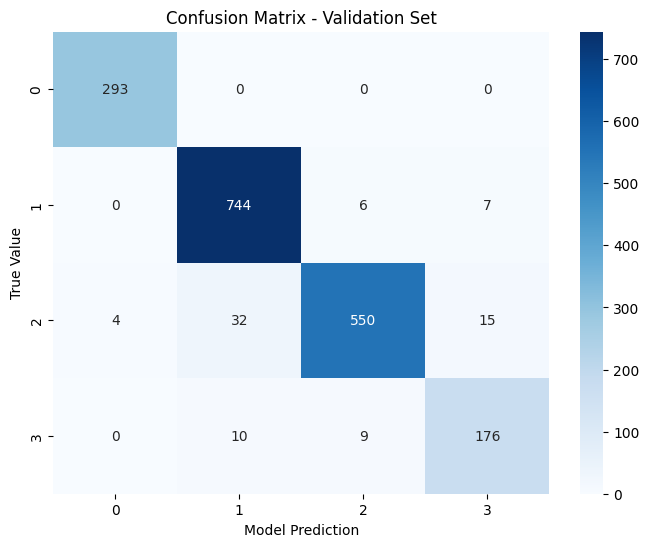


✅ Model saved successfully to Drive: /content/drive/MyDrive/Proyecto_ML/modelo_cnn_mpa_mlf.h5

Preparing test data for Kaggle...
Predicting test images...


100%|██████████| 3955/3955 [05:09<00:00, 12.77it/s]



🚀 CSV file generated successfully!
Download it from Drive: /content/drive/MyDrive/Proyecto_ML/submission_kaggle_final.csv


In [7]:
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import glob

# ==========================================
# 1. EVALUATION AND CONFUSION MATRIX
# ==========================================
print("Evaluating model on validation set...")
# Get probabilities and choose highest
y_pred_probs = modelo_cnn.predict(X_val)
y_pred = np.argmax(y_pred_probs, axis=1)

print("\n--- CLASSIFICATION REPORT (F1-Score) ---")
print(classification_report(y_val_split, y_pred, target_names=['0 People', '1 Person', '2 People', '3 People']))

# Generate and plot Confusion Matrix
cm = confusion_matrix(y_val_split, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['0', '1', '2', '3'],
            yticklabels=['0', '1', '2', '3'])
plt.title('Confusion Matrix - Validation Set')
plt.xlabel('Model Prediction')
plt.ylabel('True Value')
plt.show()

# ==========================================
# 2. SAVE MODEL
# ==========================================
ruta_modelo = ruta_drive + 'modelo_cnn_mpa_mlf.h5'
modelo_cnn.save(ruta_modelo)
print(f"\n✅ Model saved successfully to Drive: {ruta_modelo}")

# ==========================================
# 3. GENERATE KAGGLE CSV FILE
# ==========================================
print("\nPreparing test data for Kaggle...")

# Find real x_test path
rutas_png_test = glob.glob(ruta_base + 'x_test/**/*.png', recursive=True)
if len(rutas_png_test) == 0:
    raise ValueError("No images found in x_test. Check zip extraction.")
ruta_test_img_real = os.path.dirname(rutas_png_test[0]) + '/'

# Load submission example for structure
submission_df = pd.read_csv(ruta_drive + 'y_test_submission_example_v2.csv')
columna_id = submission_df.columns[0] # Usually 'Id'
columna_label = submission_df.columns[1] # Usually 'Predicted' or 'Label'

predicciones_kaggle = []

print("Predicting test images...")
for index, row in tqdm(submission_df.iterrows(), total=submission_df.shape[0]):
    # ID/Image naming logic
    img_id = int(row[columna_id])
    img_name = f"img_{img_id + 1}.png"
    img_path = os.path.join(ruta_test_img_real, img_name)

    if os.path.exists(img_path):
        # Preprocess same as training
        img = cv2.imread(img_path, cv2.IMREAD_COLOR)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img_normalized = np.array(img, dtype='float32') / 255.0

        # Expand dimensions for batch input
        img_batch = np.expand_dims(img_normalized, axis=0)

        # Predict
        pred_prob = modelo_cnn.predict(img_batch, verbose=0)
        pred_class = np.argmax(pred_prob, axis=1)[0]

        predicciones_kaggle.append(pred_class)
    else:
        print(f"⚠️ Warning: {img_name} not found. Assigning class 0.")
        predicciones_kaggle.append(0)

# Overwrite labels with predictions
submission_df[columna_label] = predicciones_kaggle

# Save final CSV to Drive
ruta_submission = ruta_drive + 'submission_kaggle_final.csv'
submission_df.to_csv(ruta_submission, index=False)

print(f"\n🚀 CSV file generated successfully!")
print(f"Download it from Drive: {ruta_submission}")

## Robust Training Iteration
Implementation of class weights and Batch Normalization to improve model stability and performance on minority classes.

In [8]:
# --- ALL IN ONE CELL: ROBUST TRAINING AND KAGGLE GENERATION ---

import numpy as np
import cv2
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# 1. CLASS WEIGHTING (To improve Class 3)
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_split),
    y=y_train_split
)
class_weights_dict = dict(enumerate(weights))
print("Calculated weights:", class_weights_dict)

# 2. ARCHITECTURE DEFINITION (Strategic Batch Normalization)
modelo_cnn = Sequential([
    # Block 1
    Conv2D(32, (3, 3), padding='same', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),

    # Block 2
    Conv2D(64, (3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),

    # Block 3
    Conv2D(128, (3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),

    # Classifier
    Flatten(),
    Dense(256),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')
])

modelo_cnn.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 3. STABLE TRAINING (Control Callbacks)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=1)

print("\nTraining model...")
historial = modelo_cnn.fit(
    X_train, y_train_split,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val_split),
    class_weight=class_weights_dict,
    callbacks=[early_stop, reduce_lr]
)

# 4. IMMEDIATE EVALUATION
print("\n--- CLASSIFICATION REPORT ---")
y_pred_val = np.argmax(modelo_cnn.predict(X_val), axis=1)
print(classification_report(y_val_split, y_pred_val, target_names=['0 Pers', '1 Pers', '2 Pers', '3 Pers']))

# 5. FAST KAGGLE SUBMISSION GENERATION
print("\nPreparing predictions for Kaggle...")
imagenes_test = []
for index, row in tqdm(submission_df.iterrows(), total=submission_df.shape[0]):
    img_id = int(row[columna_id])
    img_name = f"img_{img_id + 1}.png"
    img_path = os.path.join(ruta_test_img_real, img_name)

    img = cv2.imread(img_path, cv2.IMREAD_COLOR)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    imagenes_test.append(img)

# Block normalization and prediction
X_test_Kaggle = np.array(imagenes_test, dtype='float32') / 255.0
y_pred_kaggle = np.argmax(modelo_cnn.predict(X_test_Kaggle), axis=1)

# Save CSV
submission_df[columna_label] = y_pred_kaggle
nombre_archivo = 'submission_final_robusta.csv'
submission_df.to_csv(nombre_archivo, index=False)

print(f"\nPROCESS COMPLETE! File '{nombre_archivo}' generated.")

Calculated weights: {0: np.float64(1.5784858853721129), 1: np.float64(0.6091944536150544), 2: np.float64(0.7685339441899208), 3: np.float64(2.3596547314578005)}

Training model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - accuracy: 0.7484 - loss: 0.5675 - val_accuracy: 0.4101 - val_loss: 2.5653 - learning_rate: 0.0010
Epoch 2/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8606 - loss: 0.3069 - val_accuracy: 0.4756 - val_loss: 0.9740 - learning_rate: 0.0010
Epoch 3/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9060 - loss: 0.2209 - val_accuracy: 0.7514 - val_loss: 0.6457 - learning_rate: 0.0010
Epoch 4/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9279 - loss: 0.1642 - val_accuracy: 0.7882 - val_loss: 0.5678 - learning_rate: 0.0010
Epoch 5/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9495 - loss: 0.1170 - val_accuracy: 0.7096 - val_loss: 0.6580 - learning_rate: 0.0010
Epoch 6/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9596 - loss: 0.0920 - val_accuracy: 0.8976 - val_loss: 0.3254 - learning_rate: 0.0010
Epoch 7/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9726 - loss: 0.0609

100%|██████████| 3955/3955 [00:00<00:00, 4387.10it/s]


124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step

PROCESS COMPLETE! File 'submission_final_robusta.csv' generated.


## Final Ensemble Strategy
Training multiple models and combining their predictions through a voting mechanism to maximize accuracy for the final submission.

In [9]:
# --- ENSEMBLE WITH AUTOMATIC GOOGLE DRIVE SAVE ---

import os
import numpy as np
from scipy.stats import mode
from tqdm import tqdm
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# 1. DEFINE DRIVE PATHS
ruta_drive = '/content/drive/MyDrive/Proyecto_ML_Final/'

if not os.path.exists(ruta_drive):
    os.makedirs(ruta_drive)
    print(f"Folder created at: {ruta_drive}")

# 2. ROBUST MODEL FUNCTION
def crear_modelo():
    model = Sequential([
        Conv2D(32, (3, 3), padding='same', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
        BatchNormalization(),
        Activation('relu'),
        MaxPooling2D((2, 2)),

        Conv2D(64, (3, 3), padding='same'),
        BatchNormalization(),
        Activation('relu'),
        MaxPooling2D((2, 2)),

        Conv2D(128, (3, 3), padding='same'),
        BatchNormalization(),
        Activation('relu'),
        MaxPooling2D((2, 2)),

        Flatten(),
        Dense(256),
        BatchNormalization(),
        Activation('relu'),
        Dropout(0.5),
        Dense(4, activation='softmax')
    ])
    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# 3. LOAD AND PREPARE TEST DATA
print("Loading test images...")
imagenes_test = []
for index, row in tqdm(submission_df.iterrows(), total=submission_df.shape[0]):
    img_id = int(row[columna_id])
    img_name = f"img_{img_id + 1}.png"
    img_path = os.path.join(ruta_test_img_real, img_name)
    img = cv2.imread(img_path, cv2.IMREAD_COLOR)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    imagenes_test.append(img)
X_test_Kaggle = np.array(imagenes_test, dtype='float32') / 255.0

# 4. TRAIN 3 MODELS AND SAVE
n_modelos = 3
lista_predicciones = []

for i in range(n_modelos):
    print(f"\n--- TRAINING MODEL {i+1} OF {n_modelos} ---")

    m = crear_modelo()
    early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)

    m.fit(X_train, y_train_split,
          epochs=40, batch_size=32,
          validation_data=(X_val, y_val_split),
          class_weight=class_weights_dict,
          callbacks=[early_stop, reduce_lr],
          verbose=0)

    # SAVE MODEL TO DRIVE
    path_modelo = os.path.join(ruta_drive, f'modelo_ensemble_{i+1}.h5')
    m.save(path_modelo)
    print(f"Model {i+1} saved to Drive: {path_modelo}")

    # Predict
    preds = np.argmax(m.predict(X_test_Kaggle), axis=1)
    lista_predicciones.append(preds)

# 5. VOTING AND FINAL CSV SAVE
matriz_predicciones = np.array(lista_predicciones)
prediccion_final, _ = mode(matriz_predicciones, axis=0)
prediccion_final = prediccion_final.flatten()

submission_df[columna_label] = prediccion_final
path_csv = os.path.join(ruta_drive, 'submission_ensemble_final.csv')
submission_df.to_csv(path_csv, index=False)

print(f"\nPROCESS COMPLETE!")
print(f"Everything has been saved to your Drive at: {ruta_drive}")

Loading test images...


100%|██████████| 3955/3955 [00:00<00:00, 4761.17it/s]
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



--- TRAINING MODEL 1 OF 3 ---


Model 1 saved to Drive: /content/drive/MyDrive/Proyecto_ML_Final/modelo_ensemble_1.h5
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step

--- TRAINING MODEL 2 OF 3 ---


Model 2 saved to Drive: /content/drive/MyDrive/Proyecto_ML_Final/modelo_ensemble_2.h5
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step

--- TRAINING MODEL 3 OF 3 ---


Model 3 saved to Drive: /content/drive/MyDrive/Proyecto_ML_Final/modelo_ensemble_3.h5
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step

PROCESS COMPLETE!
Everything has been saved to your Drive at: /content/drive/MyDrive/Proyecto_ML_Final/
